# Student Health Risk Classification
## LightGBM + CatBoost OOF Ensemble and Professional Visualisations

This notebook provides a complete, reproducible workflow:

1. Installs the required Python libraries.
2. Loads `train.csv` and `test.csv`.
3. Applies data cleaning and feature engineering.
4. Runs LightGBM using the best known fixed parameters.
5. Tunes CatBoost using two Optuna trials.
6. Generates 5-fold out-of-fold and test probabilities.
7. Finds the best LightGBM–CatBoost blending weight.
8. Creates Kaggle submission files.
9. Saves technical and LinkedIn-ready charts.

Place `train.csv` and `test.csv` in the same folder as this notebook, then run all cells from top to bottom.


In [1]:
# Install all required libraries
%pip install -U numpy pandas matplotlib scikit-learn lightgbm catboost optuna

print("\n✅ Required libraries were installed.")
print("Restart the kernel only if Jupyter requests it, then run the next cell.")


   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------  9.7/9.8 MB 54.9 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 50.9 MB/s  0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3 MB 57.8 MB/s  0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 35.4 MB/s  0:00:00

  Attempting uninstall: pandas

    Found existing installation: pandas 3.0.3

   ---------------------------------------- 0/3 [pandas]
   ---------------------------------------- 0/3 [pandas]
    Uninstalling pandas-3.0.3:
   ---------------------------------------- 0/3 [pandas]
      Successfully uninstalled pandas-3.0.3
   ---------------------------------------- 0/3 [pandas]
   ---------------------------------------- 0/3 [pandas]
   ---------------------------------------- 0/3 [panda

1. Loading data
Train shape: (690088, 15)
Test shape : (295753, 14)

Target distribution:
health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: proportion, dtype: float64

2. Feature engineering

Class order: ['at-risk', 'fit', 'unhealthy']
LightGBM train shape: (690088, 29)
CatBoost train shape: (690088, 27)
CatBoost categorical features: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']

Rows used for CatBoost tuning: 200000

3. CatBoost Optuna: 2 trials


  0%|          | 0/2 [00:00<?, ?it/s]


Best CatBoost CV score: 0.948419928133501

Best CatBoost parameters:
  iterations: 1112
  learning_rate: 0.07220721098226064
  depth: 8
  l2_leaf_reg: 0.37570597138026446
  random_strength: 0.003776663327107336
  bagging_temperature: 0.46798356100860794
  border_count: 75

4. Final LightGBM + CatBoost training

Fold 1/5
LightGBM Balanced Accuracy: 0.95047136
CatBoost Balanced Accuracy: 0.94959331

Fold 2/5
LightGBM Balanced Accuracy: 0.9517533
CatBoost Balanced Accuracy: 0.95052261

Fold 3/5
LightGBM Balanced Accuracy: 0.94908601
CatBoost Balanced Accuracy: 0.94844629

Fold 4/5
LightGBM Balanced Accuracy: 0.94930888
CatBoost Balanced Accuracy: 0.94842839

Fold 5/5
LightGBM Balanced Accuracy: 0.94814861
CatBoost Balanced Accuracy: 0.94711742

5. OOF scores and best blend
LightGBM OOF Balanced Accuracy: 0.94975369
CatBoost OOF Balanced Accuracy: 0.94882167
Ensemble OOF Balanced Accuracy: 0.94978303

Best blend ratio:
LightGBM: 0.971
CatBoost: 0.029

Ensemble recall by class:
  at-risk: 

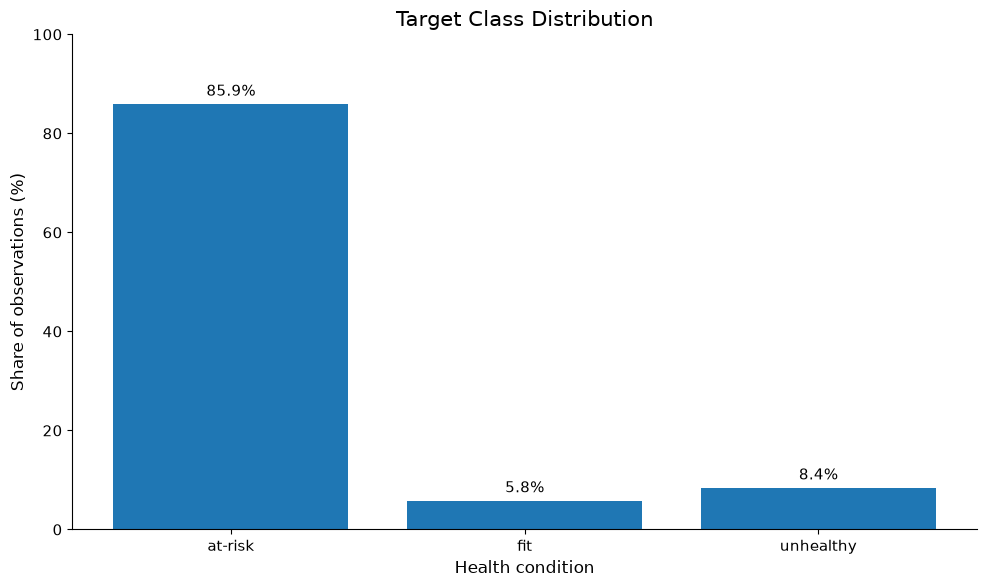

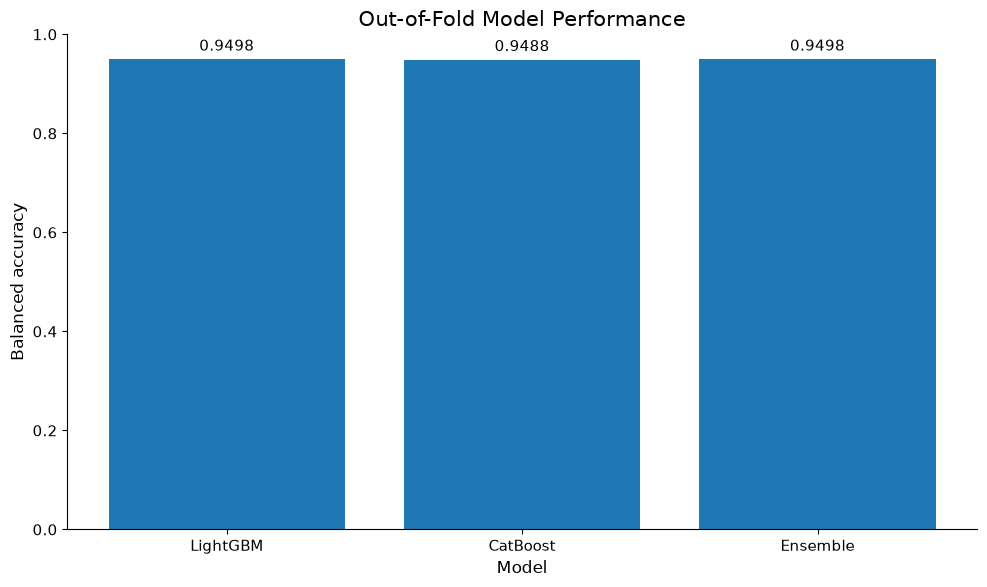

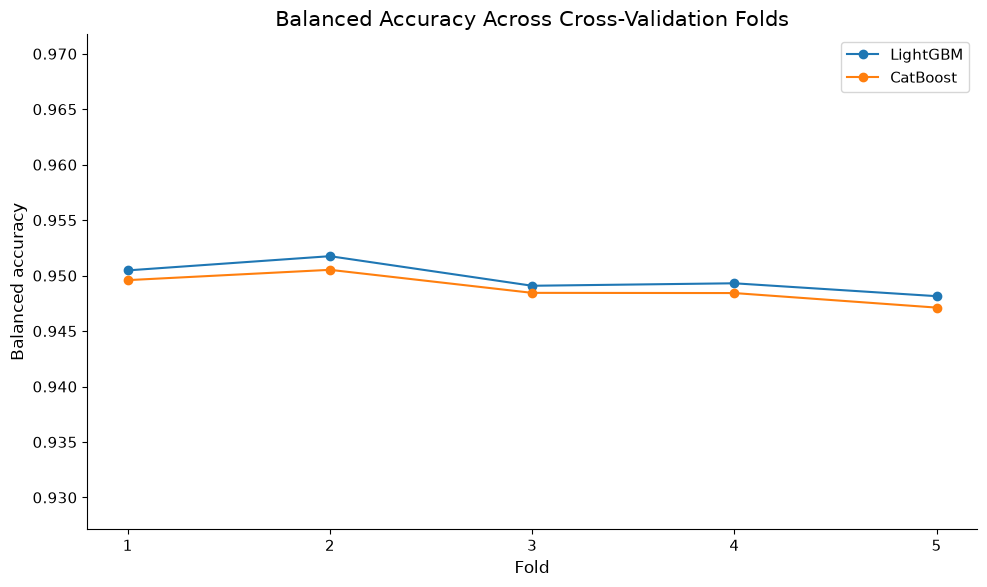

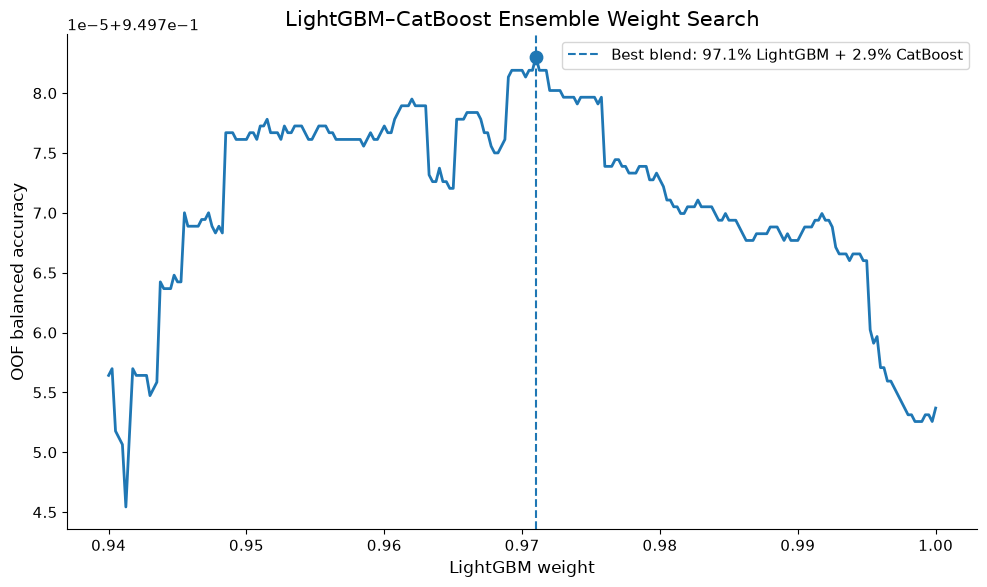

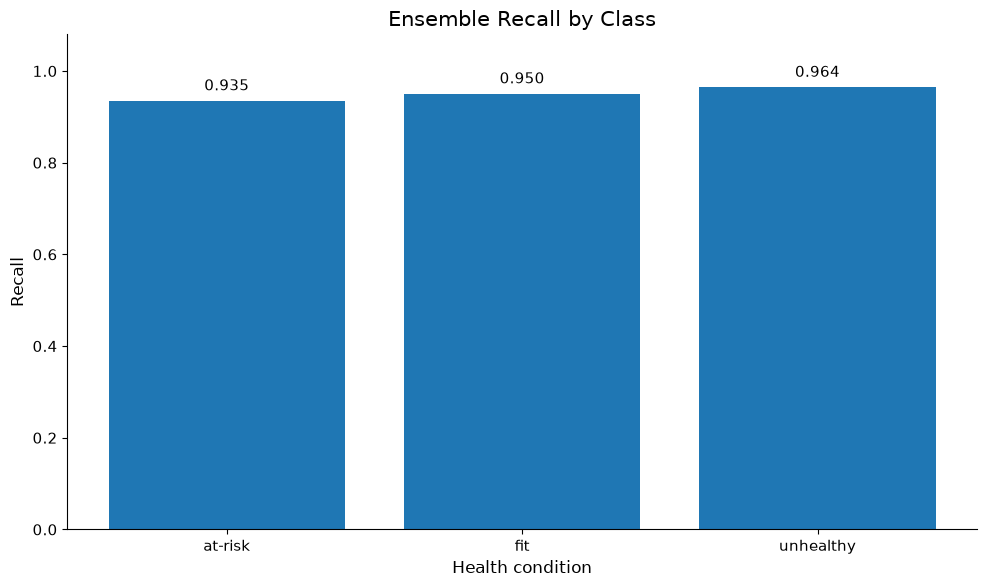

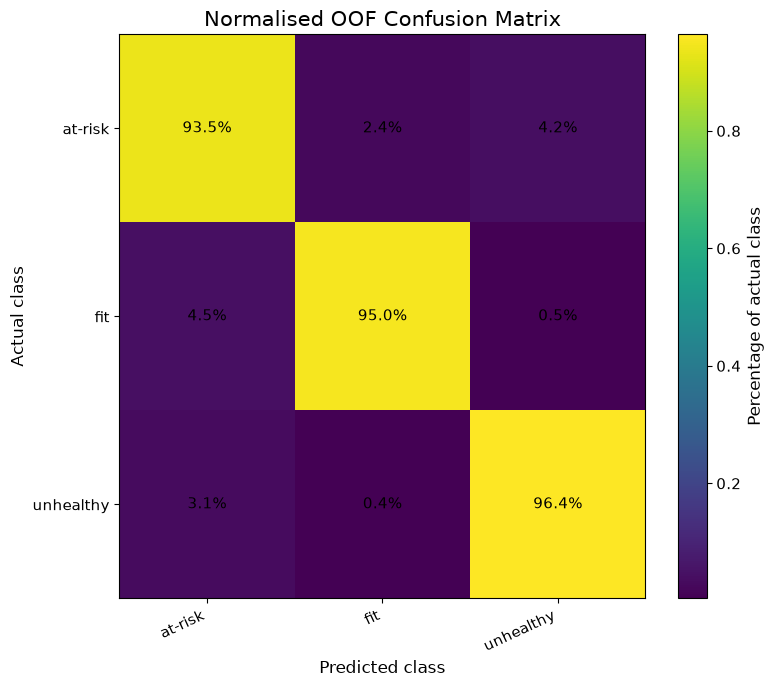

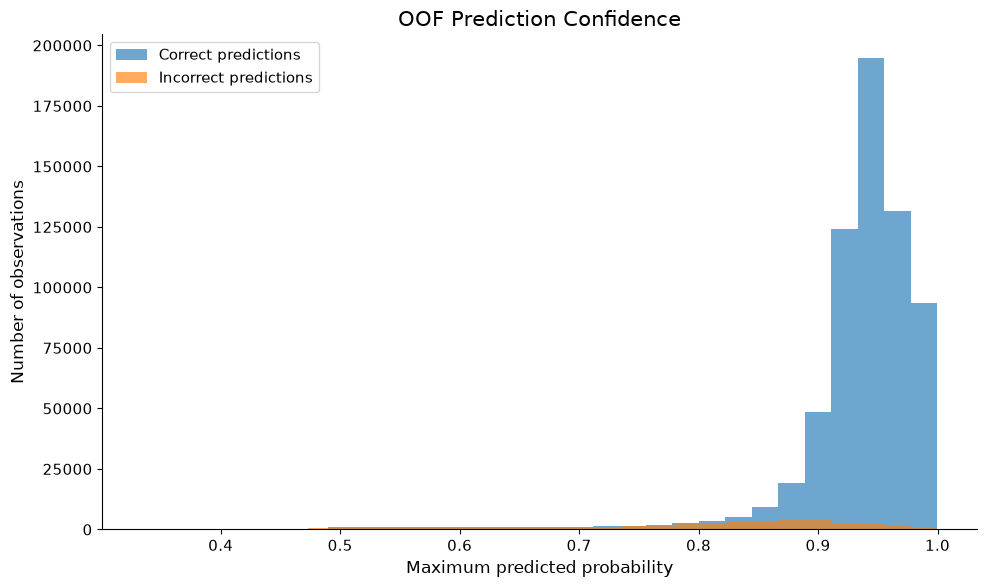

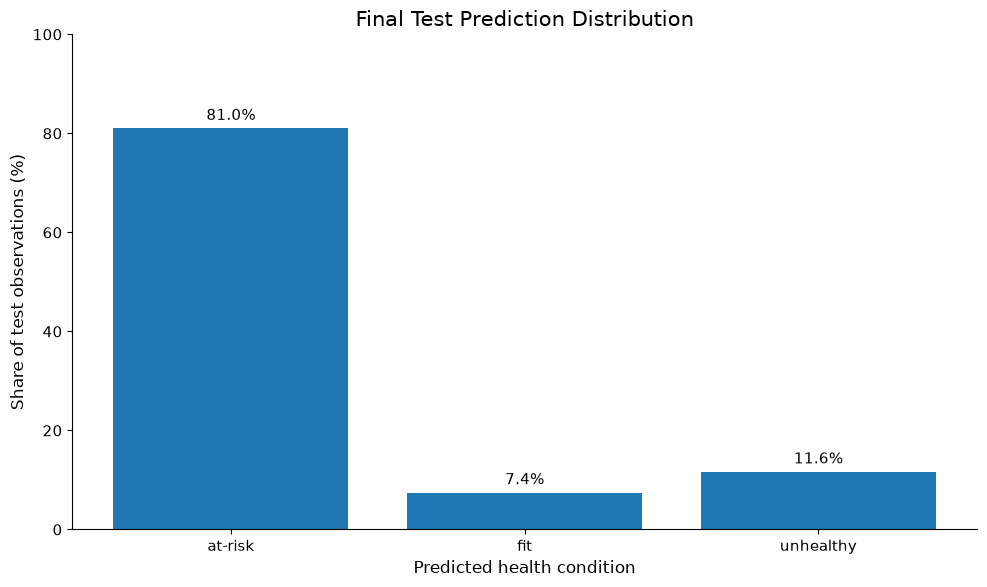


VISUALISATIONS CREATED SUCCESSFULLY

Charts directory:
D:\kaggle_health\final\charts

Generated charts:
  01_target_class_distribution.png
  02_model_performance_comparison.png
  03_fold_performance.png
  04_ensemble_weight_search.png
  05_recall_by_class.png
  06_normalised_confusion_matrix.png
  07_prediction_confidence.png
  08_test_prediction_distribution.png


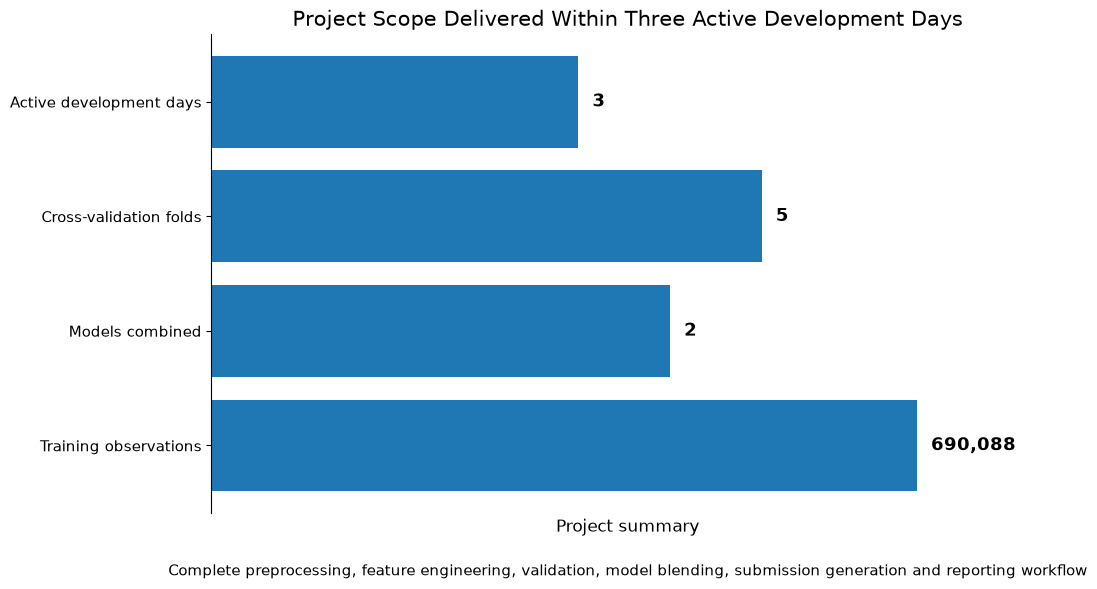


LinkedIn summary chart created: 09_project_achievement_summary.png


In [2]:
# ============================================================
# LightGBM + CatBoost OOF Ensemble
# Fixed LightGBM parameters
# CatBoost Optuna: 2 trials
# Final output: submission_lgb_catboost_ensemble.csv
# ============================================================

import gc
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna

from catboost import CatBoostClassifier
from optuna.samplers import TPESampler

from sklearn.metrics import (
    balanced_accuracy_score,
    recall_score,
    confusion_matrix,
)

from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
)

from sklearn.preprocessing import LabelEncoder


warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


# ============================================================
# 1. SETTINGS
# ============================================================

RANDOM_STATE = 42

TRAIN_FILE = "train.csv"
TEST_FILE = "test.csv"

ID_COLUMN = "id"
TARGET_COLUMN = "health_condition"

# فقط دو آزمایش برای CatBoost
CATBOOST_TRIALS = 2

# Optuna روی یک نمونه طبقه‌بندی‌شده اجرا می‌شود.
# برای استفاده از کل داده، مقدار را None قرار بده.
CATBOOST_TUNING_SAMPLE_SIZE = 200_000

CATBOOST_TUNING_FOLDS = 3
FINAL_FOLDS = 5

LIGHTGBM_EARLY_STOPPING = 70
CATBOOST_EARLY_STOPPING = 70


# ============================================================
# 2. FIXED LIGHTGBM PARAMETERS
# ============================================================

LIGHTGBM_PARAMETERS = {
    "objective": "multiclass",

    "max_depth": 6,
    "n_estimators": 1161,
    "learning_rate": 0.011617,
    "num_leaves": 21,

    "min_child_samples": 295,
    "min_child_weight": 0.020184,

    "subsample": 0.921698,
    "subsample_freq": 6,
    "colsample_bytree": 0.910144,

    "reg_alpha": 0.000272,
    "reg_lambda": 0.109937,
    "min_split_gain": 0.186370,

    "class_weight": "balanced",

    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
    "importance_type": "gain",
}


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def safe_divide(numerator, denominator):
    """
    تقسیم امن؛ اگر مخرج صفر باشد NaN تولید می‌شود.
    """

    numerator = pd.to_numeric(
        numerator,
        errors="coerce",
    )

    denominator = pd.to_numeric(
        denominator,
        errors="coerce",
    ).astype(float)

    denominator = denominator.where(
        denominator.abs() > 1e-12,
        np.nan,
    )

    return numerator / denominator


def clean_category(series):
    """
    پاک‌سازی ستون‌های دسته‌ای.
    """

    return (
        series
        .astype("string")
        .str.strip()
        .str.lower()
        .fillna("missing")
    )


# ============================================================
# 4. LOAD DATA
# ============================================================

print("=" * 75)
print("1. Loading data")
print("=" * 75)

train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

test_ids = test_df[ID_COLUMN].copy()
target_text = train_df[TARGET_COLUMN].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTarget distribution:")

print(
    target_text.value_counts(
        normalize=True
    )
)


# ============================================================
# 5. COMBINE TRAIN AND TEST
# ============================================================

train_df["is_train"] = 1
test_df["is_train"] = 0

all_df = pd.concat(
    [train_df, test_df],
    axis=0,
    ignore_index=True,
)

del train_df
del test_df

gc.collect()


# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

print("\n" + "=" * 75)
print("2. Feature engineering")
print("=" * 75)


categorical_columns = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender",
]


for column in categorical_columns:
    all_df[column] = clean_category(
        all_df[column]
    )


stress_map = {
    "low": 0,
    "medium": 1,
    "high": 2,
}

sleep_map = {
    "poor": 0,
    "average": 1,
    "good": 2,
}

activity_map = {
    "sedentary": 0,
    "moderate": 1,
    "active": 2,
}

smoking_map = {
    "no": 0,
    "occasional": 1,
    "yes": 2,
}


all_df["stress_level_num"] = (
    all_df["stress_level"]
    .map(stress_map)
)

all_df["sleep_quality_num"] = (
    all_df["sleep_quality"]
    .map(sleep_map)
)

all_df["physical_activity_level_num"] = (
    all_df["physical_activity_level"]
    .map(activity_map)
)

all_df["smoking_alcohol_num"] = (
    all_df["smoking_alcohol"]
    .map(smoking_map)
)


# ------------------------------------------------------------
# فیچرهای موفق کد اولیه
# ------------------------------------------------------------

all_df["sleep_efficiency"] = safe_divide(
    all_df["sleep_quality_num"],
    all_df["sleep_duration"],
)

all_df["activity_intensity"] = safe_divide(
    all_df["step_count"],
    all_df["exercise_duration"],
)

all_df["cardio_risk_index"] = (
    all_df["heart_rate"]
    * all_df["bmi"]
)

all_df["hydration_rate"] = safe_divide(
    all_df["water_intake"],
    all_df["exercise_duration"],
)

all_df["calories_per_step"] = safe_divide(
    all_df["calorie_expenditure"],
    all_df["step_count"],
)


# ------------------------------------------------------------
# Group-relative features
# ------------------------------------------------------------

all_df["mean_hr_by_activity"] = (
    all_df.groupby(
        "physical_activity_level",
        dropna=False,
    )["heart_rate"]
    .transform("mean")
)

all_df["hr_diff_from_mean"] = (
    all_df["heart_rate"]
    - all_df["mean_hr_by_activity"]
)


all_df["mean_stress_by_habit"] = (
    all_df.groupby(
        "smoking_alcohol",
        dropna=False,
    )["stress_level_num"]
    .transform("mean")
)

all_df["stress_diff_from_mean"] = (
    all_df["stress_level_num"]
    - all_df["mean_stress_by_habit"]
)


# ------------------------------------------------------------
# تعداد Missingها
# ------------------------------------------------------------

original_feature_columns = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake",
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender",
]

all_df["missing_count"] = (
    all_df[original_feature_columns]
    .isna()
    .sum(axis=1)
    .astype("int8")
)


all_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True,
)


train_mask = all_df["is_train"].eq(1)


# ============================================================
# 7. CATBOOST DATASET
# ============================================================

# CatBoost ستون‌های categorical اصلی را حفظ می‌کند.

X_catboost_all = all_df.drop(
    columns=[
        ID_COLUMN,
        TARGET_COLUMN,
        "is_train",
    ],
    errors="ignore",
).copy()


CATBOOST_CATEGORICAL_FEATURES = [
    column
    for column in categorical_columns
    if column in X_catboost_all.columns
]


for column in CATBOOST_CATEGORICAL_FEATURES:
    X_catboost_all[column] = (
        X_catboost_all[column]
        .fillna("missing")
        .astype(str)
    )


X_catboost = (
    X_catboost_all.loc[train_mask]
    .reset_index(drop=True)
)

X_catboost_test = (
    X_catboost_all.loc[~train_mask]
    .reset_index(drop=True)
)


del X_catboost_all
gc.collect()


# ============================================================
# 8. LIGHTGBM DATASET
# ============================================================

# نسخه‌های عددی ordinal حفظ می‌شوند.
# رشته‌های ordinal اصلی حذف می‌شوند.

X_lightgbm_all = all_df.drop(
    columns=[
        ID_COLUMN,
        TARGET_COLUMN,
        "is_train",

        "stress_level",
        "sleep_quality",
        "physical_activity_level",
        "smoking_alcohol",
    ],
    errors="ignore",
).copy()


X_lightgbm_all = pd.get_dummies(
    X_lightgbm_all,

    columns=[
        "diet_type",
        "gender",
    ],

    drop_first=False,
    dtype=np.int8,
)


X_lightgbm = (
    X_lightgbm_all.loc[train_mask]
    .reset_index(drop=True)
)

X_lightgbm_test = (
    X_lightgbm_all.loc[~train_mask]
    .reset_index(drop=True)
)


del X_lightgbm_all
del all_df

gc.collect()


# ------------------------------------------------------------
# حذف ستون‌های ثابت
# ------------------------------------------------------------

constant_columns = [
    column
    for column in X_lightgbm.columns
    if X_lightgbm[column].nunique(
        dropna=False
    ) <= 1
]


if constant_columns:

    X_lightgbm.drop(
        columns=constant_columns,
        inplace=True,
    )

    X_lightgbm_test.drop(
        columns=constant_columns,
        errors="ignore",
        inplace=True,
    )


X_lightgbm_test = X_lightgbm_test.reindex(
    columns=X_lightgbm.columns,
    fill_value=0,
)


X_lightgbm = X_lightgbm.astype(
    np.float32
)

X_lightgbm_test = X_lightgbm_test.astype(
    np.float32
)


# ============================================================
# 9. TARGET ENCODING
# ============================================================

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    target_text
)


CLASS_NAMES = list(
    label_encoder.classes_
)

NUMBER_OF_CLASSES = len(
    CLASS_NAMES
)


LIGHTGBM_PARAMETERS[
    "num_class"
] = NUMBER_OF_CLASSES


print("\nClass order:", CLASS_NAMES)

print(
    "LightGBM train shape:",
    X_lightgbm.shape,
)

print(
    "CatBoost train shape:",
    X_catboost.shape,
)

print(
    "CatBoost categorical features:",
    CATBOOST_CATEGORICAL_FEATURES,
)


# ============================================================
# 10. CATBOOST TUNING SAMPLE
# ============================================================

if (
    CATBOOST_TUNING_SAMPLE_SIZE is None
    or CATBOOST_TUNING_SAMPLE_SIZE >= len(y)
):

    tuning_indices = np.arange(
        len(y)
    )

else:

    tuning_splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=CATBOOST_TUNING_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
    )

    tuning_indices, _ = next(
        tuning_splitter.split(
            np.zeros(len(y)),
            y,
        )
    )


X_catboost_tune = (
    X_catboost.iloc[tuning_indices]
    .reset_index(drop=True)
)

y_tune = y[tuning_indices]


print(
    "\nRows used for CatBoost tuning:",
    len(y_tune),
)


# ============================================================
# 11. CATBOOST OPTUNA — ONLY 2 TRIALS
# ============================================================

def catboost_objective(trial):

    parameters = {
        "loss_function": "MultiClass",
        "eval_metric": "MultiClass",

        "iterations": trial.suggest_int(
            "iterations",
            700,
            1800,
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.08,
            log=True,
        ),

        "depth": trial.suggest_int(
            "depth",
            5,
            9,
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1e-3,
            20.0,
            log=True,
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            1e-3,
            5.0,
            log=True,
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0.0,
            3.0,
        ),

        "border_count": trial.suggest_int(
            "border_count",
            64,
            254,
        ),

        "bootstrap_type": "Bayesian",
        "auto_class_weights": "Balanced",

        "random_seed": RANDOM_STATE,
        "thread_count": -1,

        "verbose": False,
        "allow_writing_files": False,
    }


    cross_validation = StratifiedKFold(
        n_splits=CATBOOST_TUNING_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )


    fold_scores = []


    for train_index, validation_index in (
        cross_validation.split(
            X_catboost_tune,
            y_tune,
        )
    ):

        model = CatBoostClassifier(
            **parameters
        )


        model.fit(
            X_catboost_tune.iloc[
                train_index
            ],

            y_tune[
                train_index
            ],

            cat_features=(
                CATBOOST_CATEGORICAL_FEATURES
            ),

            eval_set=(
                X_catboost_tune.iloc[
                    validation_index
                ],

                y_tune[
                    validation_index
                ],
            ),

            early_stopping_rounds=(
                CATBOOST_EARLY_STOPPING
            ),

            use_best_model=True,
            verbose=False,
        )


        validation_prediction = (
            model.predict(
                X_catboost_tune.iloc[
                    validation_index
                ]
            )
            .astype(int)
            .reshape(-1)
        )


        score = balanced_accuracy_score(
            y_tune[validation_index],
            validation_prediction,
        )


        fold_scores.append(score)


        del model
        gc.collect()


    return float(
        np.mean(fold_scores)
    )


print("\n" + "=" * 75)
print("3. CatBoost Optuna: 2 trials")
print("=" * 75)


catboost_study = optuna.create_study(
    direction="maximize",

    sampler=TPESampler(
        seed=RANDOM_STATE,

        # با دو Trial عملاً دو انتخاب اولیه
        n_startup_trials=2,
    ),

    study_name="catboost_two_trials",
)


catboost_study.optimize(
    catboost_objective,

    n_trials=CATBOOST_TRIALS,

    gc_after_trial=True,
    show_progress_bar=True,
)


print(
    "\nBest CatBoost CV score:",
    catboost_study.best_value,
)


print("\nBest CatBoost parameters:")

for key, value in (
    catboost_study.best_params.items()
):
    print(
        f"  {key}: {value}"
    )


BEST_CATBOOST_PARAMETERS = {
    **catboost_study.best_params,

    "loss_function": "MultiClass",
    "eval_metric": "MultiClass",

    "bootstrap_type": "Bayesian",
    "auto_class_weights": "Balanced",

    "random_seed": RANDOM_STATE,
    "thread_count": -1,

    "verbose": False,
    "allow_writing_files": False,
}


with open(
    "best_catboost_parameters.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        catboost_study.best_params,
        file,
        indent=4,
    )


del X_catboost_tune
del y_tune

gc.collect()


# ============================================================
# 12. FINAL 5-FOLD OOF TRAINING
# ============================================================

print("\n" + "=" * 75)
print("4. Final LightGBM + CatBoost training")
print("=" * 75)


final_cross_validation = StratifiedKFold(
    n_splits=FINAL_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


oof_lightgbm = np.zeros(
    (
        len(y),
        NUMBER_OF_CLASSES,
    ),
    dtype=np.float64,
)


oof_catboost = np.zeros(
    (
        len(y),
        NUMBER_OF_CLASSES,
    ),
    dtype=np.float64,
)


test_lightgbm = np.zeros(
    (
        len(X_lightgbm_test),
        NUMBER_OF_CLASSES,
    ),
    dtype=np.float64,
)


test_catboost = np.zeros(
    (
        len(X_catboost_test),
        NUMBER_OF_CLASSES,
    ),
    dtype=np.float64,
)


lightgbm_fold_scores = []
catboost_fold_scores = []


for fold_number, (
    train_index,
    validation_index,
) in enumerate(
    final_cross_validation.split(
        X_lightgbm,
        y,
    ),
    start=1,
):

    print(
        f"\nFold {fold_number}/{FINAL_FOLDS}"
    )


    # ========================================================
    # LightGBM
    # ========================================================

    lightgbm_model = lgb.LGBMClassifier(
        **LIGHTGBM_PARAMETERS
    )


    lightgbm_model.fit(
        X_lightgbm.iloc[
            train_index
        ],

        y[
            train_index
        ],

        eval_set=[
            (
                X_lightgbm.iloc[
                    validation_index
                ],

                y[
                    validation_index
                ],
            )
        ],

        eval_metric="multi_logloss",

        callbacks=[
            lgb.early_stopping(
                stopping_rounds=(
                    LIGHTGBM_EARLY_STOPPING
                ),
                verbose=False,
            ),

            lgb.log_evaluation(
                period=0
            ),
        ],
    )


    lightgbm_validation_probability = (
        lightgbm_model.predict_proba(
            X_lightgbm.iloc[
                validation_index
            ]
        )
    )


    oof_lightgbm[
        validation_index
    ] = lightgbm_validation_probability


    test_lightgbm += (
        lightgbm_model.predict_proba(
            X_lightgbm_test
        )
        / FINAL_FOLDS
    )


    lightgbm_validation_prediction = (
        np.argmax(
            lightgbm_validation_probability,
            axis=1,
        )
    )


    lightgbm_score = (
        balanced_accuracy_score(
            y[validation_index],
            lightgbm_validation_prediction,
        )
    )


    lightgbm_fold_scores.append(
        lightgbm_score
    )


    # ========================================================
    # CatBoost
    # ========================================================

    catboost_model = CatBoostClassifier(
        **BEST_CATBOOST_PARAMETERS
    )


    catboost_model.fit(
        X_catboost.iloc[
            train_index
        ],

        y[
            train_index
        ],

        cat_features=(
            CATBOOST_CATEGORICAL_FEATURES
        ),

        eval_set=(
            X_catboost.iloc[
                validation_index
            ],

            y[
                validation_index
            ],
        ),

        early_stopping_rounds=(
            CATBOOST_EARLY_STOPPING
        ),

        use_best_model=True,
        verbose=False,
    )


    catboost_validation_probability = (
        catboost_model.predict_proba(
            X_catboost.iloc[
                validation_index
            ]
        )
    )


    oof_catboost[
        validation_index
    ] = catboost_validation_probability


    test_catboost += (
        catboost_model.predict_proba(
            X_catboost_test
        )
        / FINAL_FOLDS
    )


    catboost_validation_prediction = (
        np.argmax(
            catboost_validation_probability,
            axis=1,
        )
    )


    catboost_score = (
        balanced_accuracy_score(
            y[validation_index],
            catboost_validation_prediction,
        )
    )


    catboost_fold_scores.append(
        catboost_score
    )


    print(
        "LightGBM Balanced Accuracy:",
        round(lightgbm_score, 8),
    )

    print(
        "CatBoost Balanced Accuracy:",
        round(catboost_score, 8),
    )


    del lightgbm_model
    del catboost_model

    del lightgbm_validation_probability
    del catboost_validation_probability

    gc.collect()


# ============================================================
# 13. INDIVIDUAL OOF SCORES
# ============================================================

lightgbm_oof_prediction = np.argmax(
    oof_lightgbm,
    axis=1,
)

catboost_oof_prediction = np.argmax(
    oof_catboost,
    axis=1,
)


LIGHTGBM_OOF_SCORE = (
    balanced_accuracy_score(
        y,
        lightgbm_oof_prediction,
    )
)


CATBOOST_OOF_SCORE = (
    balanced_accuracy_score(
        y,
        catboost_oof_prediction,
    )
)


# ============================================================
# 14. FIND BEST BLEND RATIO
# ============================================================

def calculate_blend_score(
    lightgbm_weight
):

    catboost_weight = (
        1.0 - lightgbm_weight
    )


    blended_probability = (
        lightgbm_weight
        * oof_lightgbm

        + catboost_weight
        * oof_catboost
    )


    blended_prediction = np.argmax(
        blended_probability,
        axis=1,
    )


    return balanced_accuracy_score(
        y,
        blended_prediction,
    )


# ------------------------------------------------------------
# Coarse search: step = 0.01
# ------------------------------------------------------------

coarse_weights = np.linspace(
    0.0,
    1.0,
    101,
)


coarse_scores = np.array([
    calculate_blend_score(weight)

    for weight in coarse_weights
])


coarse_best_weight = float(
    coarse_weights[
        np.argmax(coarse_scores)
    ]
)


# ------------------------------------------------------------
# Fine search around best result
# ------------------------------------------------------------

fine_start = max(
    0.0,
    coarse_best_weight - 0.03,
)

fine_end = min(
    1.0,
    coarse_best_weight + 0.03,
)


fine_weights = np.linspace(
    fine_start,
    fine_end,
    241,
)


fine_scores = np.array([
    calculate_blend_score(weight)

    for weight in fine_weights
])


best_position = int(
    np.argmax(fine_scores)
)


BEST_LIGHTGBM_WEIGHT = float(
    fine_weights[best_position]
)


BEST_CATBOOST_WEIGHT = (
    1.0 - BEST_LIGHTGBM_WEIGHT
)


BEST_ENSEMBLE_SCORE = float(
    fine_scores[best_position]
)


print("\n" + "=" * 75)
print("5. OOF scores and best blend")
print("=" * 75)


print(
    "LightGBM OOF Balanced Accuracy:",
    round(LIGHTGBM_OOF_SCORE, 8),
)


print(
    "CatBoost OOF Balanced Accuracy:",
    round(CATBOOST_OOF_SCORE, 8),
)


print(
    "Ensemble OOF Balanced Accuracy:",
    round(BEST_ENSEMBLE_SCORE, 8),
)


print("\nBest blend ratio:")

print(
    "LightGBM:",
    round(BEST_LIGHTGBM_WEIGHT, 6),
)

print(
    "CatBoost:",
    round(BEST_CATBOOST_WEIGHT, 6),
)


# ============================================================
# 15. FINAL ENSEMBLE PROBABILITIES
# ============================================================

oof_ensemble_probability = (
    BEST_LIGHTGBM_WEIGHT
    * oof_lightgbm

    + BEST_CATBOOST_WEIGHT
    * oof_catboost
)


test_ensemble_probability = (
    BEST_LIGHTGBM_WEIGHT
    * test_lightgbm

    + BEST_CATBOOST_WEIGHT
    * test_catboost
)


oof_ensemble_prediction = np.argmax(
    oof_ensemble_probability,
    axis=1,
)


test_ensemble_prediction = np.argmax(
    test_ensemble_probability,
    axis=1,
)


# ============================================================
# 16. RECALL BY CLASS
# ============================================================

ensemble_recalls = recall_score(
    y,
    oof_ensemble_prediction,

    labels=np.arange(
        NUMBER_OF_CLASSES
    ),

    average=None,
)


print("\nEnsemble recall by class:")

for class_name, class_recall in zip(
    CLASS_NAMES,
    ensemble_recalls,
):

    print(
        f"  {class_name}: "
        f"{class_recall:.8f}"
    )


print("\nEnsemble confusion matrix:")

ensemble_confusion_matrix = (
    confusion_matrix(
        y,
        oof_ensemble_prediction,

        labels=np.arange(
            NUMBER_OF_CLASSES
        ),
    )
)


confusion_dataframe = pd.DataFrame(
    ensemble_confusion_matrix,

    index=[
        f"actual_{class_name}"
        for class_name in CLASS_NAMES
    ],

    columns=[
        f"predicted_{class_name}"
        for class_name in CLASS_NAMES
    ],
)


print(confusion_dataframe)


# ============================================================
# 17. CREATE THREE SUBMISSIONS
# ============================================================

lightgbm_test_prediction = np.argmax(
    test_lightgbm,
    axis=1,
)

catboost_test_prediction = np.argmax(
    test_catboost,
    axis=1,
)


submission_lightgbm = pd.DataFrame({
    ID_COLUMN: test_ids,

    TARGET_COLUMN: (
        label_encoder.inverse_transform(
            lightgbm_test_prediction
        )
    ),
})


submission_catboost = pd.DataFrame({
    ID_COLUMN: test_ids,

    TARGET_COLUMN: (
        label_encoder.inverse_transform(
            catboost_test_prediction
        )
    ),
})


submission_ensemble = pd.DataFrame({
    ID_COLUMN: test_ids,

    TARGET_COLUMN: (
        label_encoder.inverse_transform(
            test_ensemble_prediction
        )
    ),
})


submission_lightgbm.to_csv(
    "submission_lightgbm_only.csv",
    index=False,
)


submission_catboost.to_csv(
    "submission_catboost_only.csv",
    index=False,
)


submission_ensemble.to_csv(
    "submission_lgb_catboost_ensemble.csv",
    index=False,
)


# ============================================================
# 18. SAVE BLEND SEARCH RESULTS
# ============================================================

blend_search_dataframe = pd.DataFrame({
    "lightgbm_weight": fine_weights,

    "catboost_weight": (
        1.0 - fine_weights
    ),

    "balanced_accuracy": fine_scores,
})


blend_search_dataframe.to_csv(
    "blend_weight_search.csv",
    index=False,
)


# ============================================================
# 19. SAVE PROBABILITIES
# ============================================================

oof_probability_dataframe = pd.DataFrame({
    "actual_class": target_text.values,
})


test_probability_dataframe = pd.DataFrame({
    ID_COLUMN: test_ids.values,
})


for class_index, class_name in enumerate(
    CLASS_NAMES
):

    oof_probability_dataframe[
        f"lgb_probability_{class_name}"
    ] = oof_lightgbm[
        :,
        class_index
    ]


    oof_probability_dataframe[
        f"cat_probability_{class_name}"
    ] = oof_catboost[
        :,
        class_index
    ]


    oof_probability_dataframe[
        f"ensemble_probability_{class_name}"
    ] = oof_ensemble_probability[
        :,
        class_index
    ]


    test_probability_dataframe[
        f"lgb_probability_{class_name}"
    ] = test_lightgbm[
        :,
        class_index
    ]


    test_probability_dataframe[
        f"cat_probability_{class_name}"
    ] = test_catboost[
        :,
        class_index
    ]


    test_probability_dataframe[
        f"ensemble_probability_{class_name}"
    ] = test_ensemble_probability[
        :,
        class_index
    ]


oof_probability_dataframe.to_csv(
    "oof_lgb_catboost_probabilities.csv",
    index=False,
)


test_probability_dataframe.to_csv(
    "test_lgb_catboost_probabilities.csv",
    index=False,
)


# ============================================================
# 20. SAVE RESULTS SUMMARY
# ============================================================

results = {
    "lightgbm_oof_balanced_accuracy": float(
        LIGHTGBM_OOF_SCORE
    ),

    "catboost_oof_balanced_accuracy": float(
        CATBOOST_OOF_SCORE
    ),

    "ensemble_oof_balanced_accuracy": float(
        BEST_ENSEMBLE_SCORE
    ),

    "best_lightgbm_weight": float(
        BEST_LIGHTGBM_WEIGHT
    ),

    "best_catboost_weight": float(
        BEST_CATBOOST_WEIGHT
    ),

    "catboost_two_trial_cv_score": float(
        catboost_study.best_value
    ),

    "catboost_best_parameters": (
        catboost_study.best_params
    ),

    "class_order": CLASS_NAMES,
}


with open(
    "ensemble_results.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        results,
        file,
        indent=4,
    )


# ============================================================
# 21. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 75)
print("COMPLETED SUCCESSFULLY")
print("=" * 75)


print(
    "\nFinal Kaggle submission:"
    "\nsubmission_lgb_catboost_ensemble.csv"
)


print(
    "\nAdditional files:"
    "\nsubmission_lightgbm_only.csv"
    "\nsubmission_catboost_only.csv"
    "\nblend_weight_search.csv"
    "\nensemble_results.json"
    "\noof_lgb_catboost_probabilities.csv"
    "\ntest_lgb_catboost_probabilities.csv"
)


print("\nSubmission preview:")

print(
    submission_ensemble.head()
)


# ============================================================
# 22. PROFESSIONAL PROJECT VISUALISATIONS
# ============================================================

from pathlib import Path

CHART_DIRECTORY = Path("charts")
CHART_DIRECTORY.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
})


def save_and_show_chart(filename):
    plt.tight_layout()
    plt.savefig(
        CHART_DIRECTORY / filename,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()


# Chart 1: Target class distribution

class_distribution = (
    target_text
    .value_counts(normalize=True)
    .reindex(CLASS_NAMES)
    .mul(100)
)

fig, ax = plt.subplots()

bars = ax.bar(
    class_distribution.index,
    class_distribution.values,
)

ax.set_title("Target Class Distribution")
ax.set_xlabel("Health condition")
ax.set_ylabel("Share of observations (%)")
ax.set_ylim(0, max(100, class_distribution.max() * 1.10))

for bar, value in zip(
    bars,
    class_distribution.values,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save_and_show_chart(
    "01_target_class_distribution.png"
)


# Chart 2: OOF model performance comparison

model_score_names = [
    "LightGBM",
    "CatBoost",
    "Ensemble",
]

model_score_values = [
    LIGHTGBM_OOF_SCORE,
    CATBOOST_OOF_SCORE,
    BEST_ENSEMBLE_SCORE,
]

fig, ax = plt.subplots()

bars = ax.bar(
    model_score_names,
    model_score_values,
)

ax.set_title("Out-of-Fold Model Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Balanced accuracy")
ax.set_ylim(0, 1.0)

for bar, value in zip(
    bars,
    model_score_values,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center",
        va="bottom",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save_and_show_chart(
    "02_model_performance_comparison.png"
)


# Chart 3: Fold-level performance

fold_numbers = np.arange(
    1,
    FINAL_FOLDS + 1,
)

fig, ax = plt.subplots()

ax.plot(
    fold_numbers,
    lightgbm_fold_scores,
    marker="o",
    label="LightGBM",
)

ax.plot(
    fold_numbers,
    catboost_fold_scores,
    marker="o",
    label="CatBoost",
)

ax.set_title("Balanced Accuracy Across Cross-Validation Folds")
ax.set_xlabel("Fold")
ax.set_ylabel("Balanced accuracy")
ax.set_xticks(fold_numbers)
ax.set_ylim(
    max(
        0,
        min(
            min(lightgbm_fold_scores),
            min(catboost_fold_scores),
        ) - 0.02,
    ),
    min(
        1,
        max(
            max(lightgbm_fold_scores),
            max(catboost_fold_scores),
        ) + 0.02,
    ),
)
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save_and_show_chart(
    "03_fold_performance.png"
)


# Chart 4: Ensemble weight search

fig, ax = plt.subplots()

ax.plot(
    blend_search_dataframe["lightgbm_weight"],
    blend_search_dataframe["balanced_accuracy"],
    linewidth=2,
)

ax.axvline(
    BEST_LIGHTGBM_WEIGHT,
    linestyle="--",
    label=(
        f"Best blend: "
        f"{BEST_LIGHTGBM_WEIGHT:.1%} LightGBM + "
        f"{BEST_CATBOOST_WEIGHT:.1%} CatBoost"
    ),
)

ax.scatter(
    [BEST_LIGHTGBM_WEIGHT],
    [BEST_ENSEMBLE_SCORE],
    s=80,
    zorder=3,
)

ax.set_title("LightGBM–CatBoost Ensemble Weight Search")
ax.set_xlabel("LightGBM weight")
ax.set_ylabel("OOF balanced accuracy")
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save_and_show_chart(
    "04_ensemble_weight_search.png"
)


# Chart 5: Ensemble recall by class

fig, ax = plt.subplots()

bars = ax.bar(
    CLASS_NAMES,
    ensemble_recalls,
)

ax.set_title("Ensemble Recall by Class")
ax.set_xlabel("Health condition")
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.08)

for bar, value in zip(
    bars,
    ensemble_recalls,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save_and_show_chart(
    "05_recall_by_class.png"
)


# Chart 6: Normalised OOF confusion matrix

normalised_confusion_matrix = (
    ensemble_confusion_matrix
    / ensemble_confusion_matrix.sum(
        axis=1,
        keepdims=True,
    )
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(
    normalised_confusion_matrix,
    aspect="auto",
)

ax.set_title("Normalised OOF Confusion Matrix")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

ax.set_xticks(
    np.arange(NUMBER_OF_CLASSES)
)

ax.set_yticks(
    np.arange(NUMBER_OF_CLASSES)
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=25,
    ha="right",
)

ax.set_yticklabels(
    CLASS_NAMES,
)

for row_index in range(
    NUMBER_OF_CLASSES
):
    for column_index in range(
        NUMBER_OF_CLASSES
    ):
        value = normalised_confusion_matrix[
            row_index,
            column_index,
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:.1%}",
            ha="center",
            va="center",
        )

fig.colorbar(
    image,
    ax=ax,
    label="Percentage of actual class",
)

save_and_show_chart(
    "06_normalised_confusion_matrix.png"
)


# Chart 7: OOF prediction confidence

prediction_confidence = np.max(
    oof_ensemble_probability,
    axis=1,
)

correct_prediction_mask = (
    oof_ensemble_prediction == y
)

fig, ax = plt.subplots()

ax.hist(
    prediction_confidence[
        correct_prediction_mask
    ],
    bins=30,
    alpha=0.65,
    label="Correct predictions",
)

ax.hist(
    prediction_confidence[
        ~correct_prediction_mask
    ],
    bins=30,
    alpha=0.65,
    label="Incorrect predictions",
)

ax.set_title("OOF Prediction Confidence")
ax.set_xlabel("Maximum predicted probability")
ax.set_ylabel("Number of observations")
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save_and_show_chart(
    "07_prediction_confidence.png"
)


# Chart 8: Final test prediction distribution

test_prediction_distribution = (
    submission_ensemble[TARGET_COLUMN]
    .value_counts(normalize=True)
    .reindex(CLASS_NAMES)
    .fillna(0)
    .mul(100)
)

fig, ax = plt.subplots()

bars = ax.bar(
    test_prediction_distribution.index,
    test_prediction_distribution.values,
)

ax.set_title("Final Test Prediction Distribution")
ax.set_xlabel("Predicted health condition")
ax.set_ylabel("Share of test observations (%)")
ax.set_ylim(
    0,
    max(
        100,
        test_prediction_distribution.max() * 1.10,
    ),
)

for bar, value in zip(
    bars,
    test_prediction_distribution.values,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save_and_show_chart(
    "08_test_prediction_distribution.png"
)


# ============================================================
# 23. SAVE CHART METRICS
# ============================================================

chart_metrics = pd.DataFrame({
    "metric": [
        "LightGBM OOF balanced accuracy",
        "CatBoost OOF balanced accuracy",
        "Ensemble OOF balanced accuracy",
        "Best LightGBM weight",
        "Best CatBoost weight",
    ],
    "value": [
        LIGHTGBM_OOF_SCORE,
        CATBOOST_OOF_SCORE,
        BEST_ENSEMBLE_SCORE,
        BEST_LIGHTGBM_WEIGHT,
        BEST_CATBOOST_WEIGHT,
    ],
})

chart_metrics.to_csv(
    CHART_DIRECTORY / "chart_metrics.csv",
    index=False,
)


print("\n" + "=" * 75)
print("VISUALISATIONS CREATED SUCCESSFULLY")
print("=" * 75)

print(
    f"\nCharts directory:\n"
    f"{CHART_DIRECTORY.resolve()}"
)

print("\nGenerated charts:")

for chart_path in sorted(
    CHART_DIRECTORY.glob("*.png")
):
    print(
        f"  {chart_path.name}"
    )


# ============================================================
# 25. LINKEDIN ACHIEVEMENT SUMMARY CHART
# ============================================================

project_summary_labels = [
    "Training observations",
    "Models combined",
    "Cross-validation folds",
    "Active development days",
]

project_summary_display = [
    f"{len(y):,}",
    "2",
    str(FINAL_FOLDS),
    "3",
]

# Values below are used only to create a visually balanced infographic.
# The true project values are printed as labels beside each bar.
project_summary_visual_widths = [
    100,
    65,
    78,
    52,
]

fig, ax = plt.subplots(
    figsize=(11, 6)
)

bars = ax.barh(
    project_summary_labels,
    project_summary_visual_widths,
)

ax.set_title(
    "Project Scope Delivered Within Three Active Development Days"
)

ax.set_xlabel(
    "Project summary"
)

ax.set_xlim(
    0,
    118,
)

ax.set_xticks([])

for bar, display_value in zip(
    bars,
    project_summary_display,
):
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        display_value,
        va="center",
        fontweight="bold",
        fontsize=13,
    )

ax.text(
    0.5,
    -0.13,
    (
        "Complete preprocessing, feature engineering, validation, "
        "model blending, submission generation and reporting workflow"
    ),
    transform=ax.transAxes,
    ha="center",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

save_and_show_chart(
    "09_project_achievement_summary.png"
)

print(
    "\nLinkedIn summary chart created: "
    "09_project_achievement_summary.png"
)


## Main outputs

After successful execution, the most important files are:

- `submission_lgb_catboost_ensemble.csv` — final Kaggle submission
- `submission_lightgbm_only.csv` — LightGBM-only benchmark
- `submission_catboost_only.csv` — CatBoost-only benchmark
- `ensemble_results.json` — final validation scores, weights and parameters
- `blend_weight_search.csv` — ensemble-weight search results
- `charts/` — all technical and LinkedIn-ready visualisations

Recommended LinkedIn images:

1. `02_model_performance_comparison.png`
2. `04_ensemble_weight_search.png`
3. `05_recall_by_class.png`
4. `06_normalised_confusion_matrix.png`
5. `09_project_achievement_summary.png`
